# In 2020, how did higher percentages of frequent physical or mental distress moderate the relationship between environmental/ socioeconomic factors and COVID19 cases? 

# Project One

In [187]:

# ! pip install -q pandas
# ! pip install -q pyppeteer
# ! pip install -q qeds
# %pip install numpy
# ! pip install -q pandas
# ! pip install -q pyppeteer
# ! pip install -q qeds
# ! pip install -q matplotlib
# ! pip install -q tabulate
# ! pip install -q statsmodels
# ! pip install -q stargazer
# ! pip install -q qeds fiona geopandas  gensim folium pyLDAvis descartes
#! pip install -q great_tables
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML
from tabulate import tabulate
import geopandas as gpd
from shapely.geometry import Point
import statsmodels.formula.api as smf
from great_tables import GT
from IPython.display import display
import matplotlib.patches as mpatches

%matplotlib inline
# activate plot theme
#import qeds
#qeds.themes.mpl_style();


## Introduction

- Source of Data
    * My dataset comes from a combination of data sources. The socioeconomic factors data comes from the US CDC metrics of "social vulnerability" and natural and man-made disasters. The weather data comes from the NOAA Global Surface Summary of the day, which links each county to a nearby weather station. Also, my dataset uses the County Health Rankings Data a dataset that contains many measures of community health. 
- Background
    * Many studies have studied the link between weather and COVID19 cases. The consensus is usually that warmer weather leads to more cases, but the issue is that socioeconomic status could be different in warmer areas and that could be a confounder. In my research, I want to affirm that relationship plus explore an additional aspect of consideration known as physical and mental stress. I want to see how this factor interacts with what we already know. 
- Research Question
    * In 2020, how did higher percentages of frequent physical or mental distress moderate the relationship between environmental/socioeconomic factors and COVID19 cases across US counties, specifically California?
- Findings
    * (put this part later)
- Citations
    * Benita, F., Rebollar-Ruelas, L., & Gaytán-Alfaro, E. D. (2022). What have we learned about socioeconomic inequalities in the spread of COVID-19? A systematic review. Sustainable cities and society, 86, 104158. https://doi.org/10.1016/j.scs.2022.104158
    * Han, Y., Zhao, W., & Pereira, P. (2022). Global COVID-19 pandemic trends and their relationship with meteorological variables, air pollutants and socioeconomic aspects. Environmental research, 204(Pt C), 112249. https://doi.org/10.1016/j.envres.2021.112249
    * Sarkodie, S. A., & Owusu, P. A. (2021). Global effect of city-to-city air pollution, health conditions, climatic & socio-economic factors on COVID-19 pandemic. The Science of the total environment, 778, 146394. https://doi.org/10.1016/j.scitotenv.2021.146394
    * Ahmed, J., Jaman, M. H., Saha, G., & Ghosh, P. (2021). Effect of environmental and socio-economic factors on the spreading of COVID-19 at 70 cities/provinces. Heliyon, 7(5), e06979. https://doi.org/10.1016/j.heliyon.2021.e06979 
    * Zhang, X., Maggioni, V., Houser, P., Xue, Y., & Mei, Y. (2022). The impact of weather condition and social activity on COVID-19 transmission in the United States. Journal of environmental management, 302(Pt B), 114085. https://doi.org/10.1016/j.jenvman.2021.114085
    * Ganslmeier, M., Furceri, D., & Ostry, J. D. (2021). The impact of weather on COVID-19 pandemic. Scientific reports, 11(1), 22027. https://doi.org/10.1038/s41598-021-01189-3
- Variables
    * X-variables = mean_temp, dewpoint, windspeed, percent_frequent_physical_distress, percent_frequent_mental_distress, percent_no_highschool_diploma, average_daily_pm2_5, unemployment rate, high_school_graduation_rate, percent_limited_access_to_healthy_foods, personal income, real_gdp_2020
    * Y-variable = Cases
- Rationale
    * I chose these variables because of their possible connection to COVID19 cases. Some studies like Ganslmeier et al. (2021) suggest a negative correlation between temperature, humidity, windspeed to COVID19 cases and I wish to explore that correlation with my temperature, dewpoint, and wind speed variables. Also, since Han et al. (2020) mention that the interaction of different types of pollution has a strong impact on cases, I included the PM2.5 variable to explore that effect. The physical and mental distress variables are there to add an additional vector for exploration. I wonder how those variables can interact with the already explored effects of other variables on COVID19 cases. Then I included some socioeconomic variables to cover their potential effect on COVID19 cases. For example, Benita et al. (2022) concludes that income inequality is positively correlated with transmission of the virus. I included education variables, measures of personal income, GDP, unemployment rate as socioeconomic variables. I think it is valuable to explore this since many research have stated there are limitations reducing the accuracy of their research.



## Data Cleaning and Loading

In [90]:
# Load datasets and do some filtering 


# Load main data and filter for California only
covid_health_weather = pd.read_csv("C:/Users/Pikachu/OneDrive - University of Toronto/W 2024/ECO225/ECO225 Project/eco225-project-code-r-lee1888/Data/US_counties_COVID19_health_weather_data.csv")
covid_health_weather = covid_health_weather[covid_health_weather['state'] == 'California']

# Get the number of rows and columns in the dataframe
num_rows, num_columns = covid_health_weather.shape
print(f'The dataframe has {num_rows} rows and {num_columns} columns.')


# Load the data for California GDP and Income and filter for 2020 only
# Remove all year columns except for 2020
ca_gdp_2020 = pd.read_csv("c:/Users/Pikachu/OneDrive - University of Toronto/W 2024/ECO225/ECO225 Project/eco225-project-code-r-lee1888/Data/CAGDP1_CA_2001_2023.csv")
ca_gdp_2020 = ca_gdp_2020[['GeoFIPS', 'GeoName', 'Region', 'TableName', 'LineCode', 'IndustryClassification', 'Description', 'Unit', '2020']]

ca_inc_2020 = pd.read_csv("c:/Users/Pikachu/OneDrive - University of Toronto/W 2024/ECO225/ECO225 Project/eco225-project-code-r-lee1888/Data/CAINC1_CA_1969_2023.csv")
ca_inc_2020 = ca_inc_2020[['GeoFIPS', 'GeoName', 'Region', 'TableName', 'LineCode', 'IndustryClassification', 'Description', 'Unit', '2020']]

ca_unemp_2020 = pd.read_csv("c:/Users/Pikachu/OneDrive - University of Toronto/W 2024/ECO225/ECO225 Project/eco225-project-code-r-lee1888/Data/UnemploymentReport.csv")
ca_unemp_2020 = ca_unemp_2020[['FIPS', 'Name', '2020']]

ca_gdp_2020 = ca_gdp_2020[ca_gdp_2020['LineCode'] == 1]
ca_pop_2020 = ca_inc_2020[ca_inc_2020['LineCode'] == 2]
ca_inc_2020 = ca_inc_2020[ca_inc_2020['LineCode'] == 3]
# Rename the 2020 column to real_gdp_2020
ca_gdp_2020.rename(columns = {'2020': 'real_gdp_2020'}, inplace = True)
# Rename to 2020 column to personal_income_capita_2020
ca_inc_2020.rename(columns = {'2020': 'personal_income_capita_2020'}, inplace = True)
# Rename the 2020 column to unemployment_rate_2020
ca_unemp_2020.rename(columns = {'2020': 'unemployment_rate_2020'}, inplace = True)

ca_pop_2020.rename(columns = {'2020': 'population_2020'}, inplace = True)

# Convert 'FIPS' column to string and remove any extra characters
ca_unemp_2020['FIPS'] = ca_unemp_2020['FIPS'].astype(str).str.replace("'", '').str.strip().str.replace('.0', '').str.zfill(5)
ca_gdp_2020['GeoFIPS'] = ca_gdp_2020['GeoFIPS'].astype(str).str.replace('"', '').str.strip().str.zfill(5)
ca_inc_2020['GeoFIPS'] = ca_inc_2020['GeoFIPS'].astype(str).str.replace('"', '').str.strip().str.zfill(5)
ca_pop_2020['GeoFIPS'] = ca_pop_2020['GeoFIPS'].astype(str).str.replace('"', '').str.strip().str.zfill(5)

# Convert 'fips' column to string to ensure the keys are of the same type
covid_health_weather['fips'] = covid_health_weather['fips'].astype(str).str.replace('"', '').str.strip().str.zfill(5)

# Merge the new datasets into the main dataset using inner join
covid_health_weather = covid_health_weather.merge(ca_gdp_2020, left_on='fips', right_on='GeoFIPS', how='outer')
covid_health_weather = covid_health_weather.merge(ca_pop_2020, left_on='fips', right_on='GeoFIPS', how='outer')
covid_health_weather = covid_health_weather.merge(ca_unemp_2020, left_on='fips', right_on='FIPS', how='outer')
covid_health_weather = covid_health_weather.merge(ca_inc_2020, left_on='fips', right_on='GeoFIPS', how='outer')

# Create a gdp per capita column
covid_health_weather['real_gdp_per_capita_2020'] = covid_health_weather['real_gdp_2020'] / covid_health_weather['population_2020']

# Change date column to datetime
covid_health_weather['date'] = pd.to_datetime(covid_health_weather['date'])
# Reduce the dataframe to the specified columns
covid_health_weather_reduced = covid_health_weather[['mean_temp', 'dewpoint', 'wind_speed', 'percent_frequent_physical_distress', 'percent_frequent_mental_distress', 'percent_no_highschool_diploma', 'average_daily_pm2_5', 'unemployment_rate_2020', 'high_school_graduation_rate', 'percent_limited_access_to_healthy_foods', 'personal_income_capita_2020', 'real_gdp_2020']]

The dataframe has 15226 rows and 227 columns.


In [190]:
# mean_temp, dewpoint, windspeed, percent_frequent_physical_distress, percent_frequent_mental_distress, percent_no_highschool_diploma, average_daily_pm2_5, unemployment rate, high_school_graduation_rate, percent_limited_access_to_healthy_foods, personal income, real_gdp_2020
# Creating dataframe with unique values per county


# Create a new dataset that lists the number of cases for each county in 2020
cases_per_county_2020 = covid_health_weather.groupby('county')[['cases']].max().reset_index()
cases_per_county_2020.rename(columns={'cases': 'total_cases_2020'}, inplace=True)
#print(cases_per_county_2020)


# Create a new dataset that calculates the average of each variable for each county
avg_per_county = covid_health_weather.groupby('county')[
    [ 
        'real_gdp_per_capita_2020', 
        'unemployment_rate_2020', 
        'percent_frequent_physical_distress', 
        'percent_frequent_mental_distress', 
        'percent_no_highschool_diploma', 
        'high_school_graduation_rate', 
        'percent_limited_access_to_healthy_foods', 
        'personal_income_capita_2020'
    ]
].mean().reset_index()
avg_per_county.columns = ['avg_' + col if col not in ['county'] else col for col in avg_per_county.columns]
#print(avg_per_county)

# Merge the two datasets cases_per_county_2020 and avg_per_county
depaneled_data = avg_per_county.merge(cases_per_county_2020, on='county', how='outer')
# Add lat and lon to dataset
depaneled_data_geo = depaneled_data.merge(covid_health_weather[['county', 'lat', 'lon', 'population_2020']].drop_duplicates(), on='county', how='left')

# Create total cases per capita column
depaneled_data_geo['total_cases_per_capita'] = depaneled_data_geo['total_cases_2020'] / depaneled_data_geo['population_2020']

# create an index of distress
depaneled_data_geo['distress_index'] = (
    depaneled_data_geo['avg_percent_frequent_physical_distress'] + 
    depaneled_data_geo['avg_percent_frequent_mental_distress'] + 
    depaneled_data_geo['avg_unemployment_rate_2020'] 
)


## Summary Statistics

In [191]:
# Generate summary statistics for the dataset 
summary_stats = covid_health_weather[['cases', 'mean_temp', 'real_gdp_2020', 'personal_income_capita_2020', 'dewpoint', 'wind_speed',
                                       'percent_frequent_physical_distress', 'percent_frequent_mental_distress', 'percent_no_highschool_diploma',
                                         'average_daily_pm2_5', 'high_school_graduation_rate','unemployment_rate_2020',
                                           'percent_limited_access_to_healthy_foods']].describe()
summary_stats = summary_stats.transpose()
summary_stats = summary_stats.round(2)

# Capitalize and remove underscore from index column
summary_stats.index = summary_stats.index.str.replace('_', ' ').str.title()

#Remove 25%, 50%, 75%, and max columns from summary_stats
summary_stats_half1 = summary_stats.drop(columns=['25%', '50%', '75%', 'max'])
# Format the new table
display(summary_stats_half1)

# Remove count, mean, std, and min columns from summary_stats
summary_stats_half2 = summary_stats.drop(columns=['count', 'mean', 'std', 'min'])

display(summary_stats_half2)






,count,mean,std,min
Cases,15226.0,8284.85,2.903655e+04,1.00
Mean Temp,14250.0,66.03,1.287000e+01,14.50
Real Gdp 2020,15227.0,57187227.54,1.241237e+08,91114.00
Personal Income Capita 2020,15227.0,63159.12,2.457438e+04,33262.00
Dewpoint,13213.0,44.34,1.067000e+01,-9.30
Wind Speed,13740.0,5.27,2.820000e+00,0.00
Percent Frequent Physical Distress,15226.0,11.20,1.540000e+00,8.34
Percent Frequent Mental Distress,15226.0,12.07,1.350000e+00,8.71
Percent No Highschool Diploma,15226.0,16.44,7.200000e+00,5.80
Average Daily Pm2 5,15226.0,10.24,2.850000e+00,5.60


,25%,50%,75%,max
Cases,57.00,621.00,5397.75,4.307130e+05
Mean Temp,57.20,65.85,74.60,1.096000e+02
Real Gdp 2020,2026350.00,9115222.00,44416463.00,2.933320e+09
Personal Income Capita 2020,47615.00,56163.00,68907.00,1.453930e+05
Dewpoint,38.30,46.30,52.40,7.610000e+01
Wind Speed,3.40,4.70,6.50,2.590000e+01
Percent Frequent Physical Distress,10.10,11.06,12.42,1.530000e+01
Percent Frequent Mental Distress,11.27,11.97,13.25,1.504000e+01
Percent No Highschool Diploma,11.00,13.70,21.20,3.300000e+01
Average Daily Pm2 5,8.70,9.60,11.00,1.970000e+01


- Mean_temp is mean temperature. The median appears to be around 18.3 degrees celsius or 65 degrees fahrenheit, but temperature can vary between 14.5 F and 109.6 F. We will connect these varying temps to cases through analysis
- cases counts number of covid19 cases for that city on that day. This will be our main response variable
- real gdp in 2020 is expressed in terms of 2017 dollars. It is one of the key statistics in measuring economic wellbeing of a county and will be one our socioeconomic variables that we are connecting to covid19 cases. GDP could be negatively correlated with cases
- We use personal income to measure income as a socioeconomic variable that can connect to number of cases. Lower income could lead to more cases
- Dewpoint is the temperature the air needs to be cooled to reach a relative humidity of 100%. This is a measure of the moisture in the air. We will use this to predict cases
- Percent frequent and mental distress potentially interacts with cases. We will explore how higher levels of distress impact cases. We will explore how this number interacts with the other factors
- High school graduation rate, umemployment rate, access to healthy goods are some rate based economic variables we will explore on how they are correlated with cases

In [192]:
# Define thresholds for high physical and mental distress
high_physical_distress_threshold = covid_health_weather['percent_frequent_physical_distress'].quantile(0.75)
high_mental_distress_threshold = covid_health_weather['percent_frequent_mental_distress'].quantile(0.75)

# Filter the data for high physical and mental distress
high_distress_data = covid_health_weather[
    (covid_health_weather['percent_frequent_physical_distress'] >= high_physical_distress_threshold) &
    (covid_health_weather['percent_frequent_mental_distress'] >= high_mental_distress_threshold)
]

summary_stats_hd = high_distress_data[['cases', 'mean_temp', 'real_gdp_2020', 'personal_income_capita_2020', 'dewpoint', 'wind_speed',
                                       'percent_frequent_physical_distress', 'percent_frequent_mental_distress', 'percent_no_highschool_diploma',
                                         'average_daily_pm2_5', 'high_school_graduation_rate','unemployment_rate_2020',
                                           'percent_limited_access_to_healthy_foods']].describe()
summary_stats_hd = summary_stats_hd.transpose()
summary_stats_hd = summary_stats_hd.round(2)
# Capitalize and remove underscore from index column
summary_stats_hd.index = summary_stats_hd.index.str.replace('_', ' ').str.title()

#Remove 25%, 50%, 75%, and max columns from summary_stats
summary_stats_half1 = summary_stats_hd.drop(columns=['25%', '50%', '75%', 'max'])
# Format the new table
display(summary_stats_half1)

# Remove count, mean, std, and min columns from summary_stats
summary_stats_half2 = summary_stats_hd.drop(columns=['count', 'mean', 'std', 'min'])

display(summary_stats_half2)


,count,mean,std,min
Cases,2774.0,4048.87,7687.30,1.00
Mean Temp,2608.0,67.96,13.87,14.50
Real Gdp 2020,2774.0,9628559.45,12763540.96,107899.00
Personal Income Capita 2020,2774.0,46779.39,9428.51,33262.00
Dewpoint,2118.0,44.65,10.10,-3.90
Wind Speed,2357.0,4.98,2.55,0.20
Percent Frequent Physical Distress,2774.0,13.30,0.83,12.54
Percent Frequent Mental Distress,2774.0,13.78,0.47,13.27
Percent No Highschool Diploma,2774.0,21.48,8.85,8.90
Average Daily Pm2 5,2774.0,11.39,4.40,5.60


,25%,50%,75%,max
Cases,22.00,339.00,4296.00,43860.00
Mean Temp,56.80,68.60,78.90,102.30
Real Gdp 2020,783182.00,6201866.00,9115222.00,45610265.00
Personal Income Capita 2020,43949.00,44409.00,45909.00,74115.00
Dewpoint,38.42,45.90,51.78,76.10
Wind Speed,3.30,4.60,6.00,18.10
Percent Frequent Physical Distress,12.66,12.82,13.74,15.30
Percent Frequent Mental Distress,13.48,13.61,13.91,15.04
Percent No Highschool Diploma,11.70,17.80,31.40,33.00
Average Daily Pm2 5,7.80,8.90,14.00,19.70


- This table is the summary statistics for the subgroup where distress is higher than the 75th quantile. I will use this subgroup to explore the effect of high distress on cases

## Plots

In [193]:

# # 1. **COVID-19 Cases Over Time**:
# #     - Plot the number of COVID-19 cases over time to see the trend.

# covid_health_weather.groupby('date')['cases'].sum().plot(kind='line', title='COVID-19 Cases Over Time') 
# plt.xlabel('Date')
# plt.ylabel('Number of Cases')
# plt.show()



# # 2. **COVID-19 Cases vs. Mean Temperature**:
# #     - Scatter plot to see the relationship between COVID-19 cases and mean temperature.
  
# plt.scatter(covid_health_weather['mean_temp'], covid_health_weather['cases'])
# plt.title('COVID-19 Cases vs. Mean Temperature')
# plt.xlabel('Mean Temperature (°F)')
# plt.ylabel('Number of Cases')
# plt.show()
  
# # 3. **COVID-19 Cases vs. Real GDP per Capita**:
# #     - Scatter plot to see the relationship between COVID-19 cases and real GDP per capita.

# plt.scatter(covid_health_weather['real_gdp_per_capita_2020'], covid_health_weather['cases'])
# plt.title('COVID-19 Cases vs. Real GDP per Capita')
# plt.xlabel('Real GDP per Capita (2017 dollars)')
# plt.ylabel('Number of Cases')
# plt.show()
    

    

# 5. **COVID-19 Cases vs. Percent Frequent Mental Distress**:
#     - Scatter plot to see the relationship between COVID-19 cases and percent frequent mental distress.

# plt.scatter(covid_health_weather['percent_frequent_mental_distress'], covid_health_weather['cases'])
# plt.title('COVID-19 Cases vs. Percent Frequent Mental Distress')
# plt.xlabel('Percent Frequent Mental Distress')
# plt.ylabel('Number of Cases')
# plt.show()


# plt.scatter(covid_health_weather['percent_frequent_physical_distress'], covid_health_weather['cases'])
# plt.title('COVID-19 Cases vs. Percent Frequent Physical Distress')
# plt.xlabel('Percent Frequent Physical Distress')
# plt.ylabel('Number of Cases')
# plt.show()
    

# 6. **COVID-19 Cases vs. Unemployment Rate**:
#     - Scatter plot to see the relationship between COVID-19 cases and unemployment rate.

# plt.scatter(covid_health_weather['unemployment_rate_2020'], covid_health_weather['cases'])
# plt.title('COVID-19 Cases vs. Unemployment Rate')
# plt.xlabel('Unemployment Rate (%)')
# plt.ylabel('Number of Cases')
# plt.show()

# New Plots

# Plot 1 (time series of cases )

    



# Project 2

## Message

In [194]:
# Create a cases by population column in covid_health_weather
covid_health_weather['cases_by_population'] = covid_health_weather['cases'] / covid_health_weather['population_2020']



## Regression


(Put the first point of part 4 in the rubric here)(Put some in-text citations)

In [213]:
# Regression without controls
X1 = covid_health_weather[['percent_frequent_physical_distress', 'percent_frequent_mental_distress']]
X1 = sm.add_constant(X1)  # Add a constant term to the predictors
y = covid_health_weather['cases']
model1 = sm.OLS(y, X1, missing = 'drop').fit()

# Regression with some controls
X2 = covid_health_weather[['percent_frequent_physical_distress', 'percent_frequent_mental_distress', 'personal_income_capita_2020', 'unemployment_rate_2020']]
X2 = sm.add_constant(X2)  # Add a constant term to the predictors
model2 = sm.OLS(y, X2, missing = 'drop').fit()


# Regression with more controls
X3 = covid_health_weather[['percent_frequent_physical_distress', 'percent_frequent_mental_distress', 'personal_income_capita_2020', 'unemployment_rate_2020', 'real_gdp_per_capita_2020']]
X3 = sm.add_constant(X3)  # Add a constant term to the predictors
model3 = sm.OLS(y, X3, missing = 'drop').fit()

# Regression with all controls
X4 = covid_health_weather[['percent_frequent_physical_distress', 'percent_frequent_mental_distress', 'personal_income_capita_2020', 'unemployment_rate_2020', 'real_gdp_per_capita_2020', 'percent_no_highschool_diploma', 'average_daily_pm2_5']]
X4 = sm.add_constant(X4)  # Add a constant term to the predictors
model4 = sm.OLS(y, X4, missing = 'drop').fit()


# Create a Stargazer summary table for all models
stargazer = Stargazer([model1, model2, model3, model4])
stargazer.covariate_order(['const', 'percent_frequent_physical_distress', 'percent_frequent_mental_distress', 'personal_income_capita_2020', 'unemployment_rate_2020', 'real_gdp_per_capita_2020', 'percent_no_highschool_diploma', 'average_daily_pm2_5'])
HTML(stargazer.render_html())
# # Save the Stargazer summary table to an HTML file
# with open('regression_summary.html', 'w') as f:
#     f.write(stargazer.render_html())

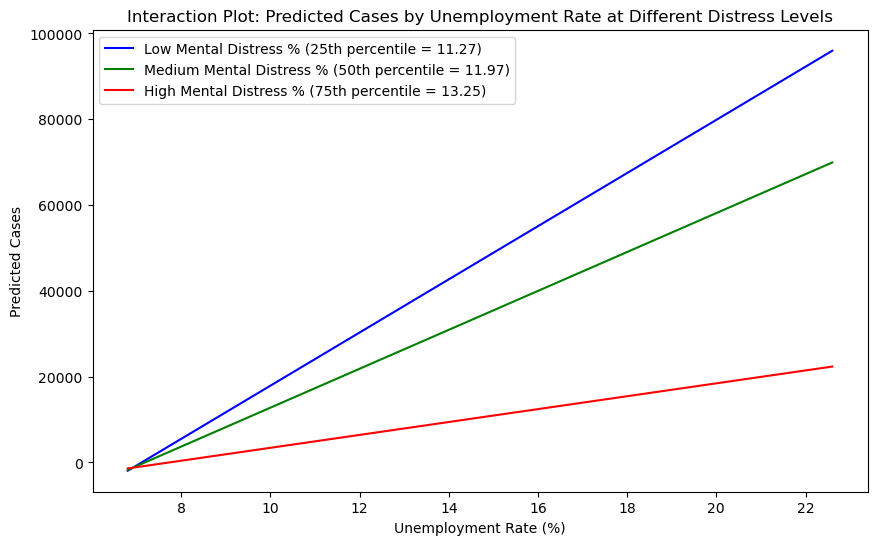

In [214]:


# Fit a regression model including the interaction term
model = smf.ols('cases ~ unemployment_rate_2020 * percent_frequent_mental_distress', data=covid_health_weather).fit()

# Generate a range of values for the environmental/socioeconomic factor
env_range = np.linspace(covid_health_weather['unemployment_rate_2020'].min(), covid_health_weather['unemployment_rate_2020'].max(), 100)

# Define distress levels (e.g., using percentiles from your data)
low_distress = covid_health_weather['percent_frequent_mental_distress'].quantile(0.25)
med_distress = covid_health_weather['percent_frequent_mental_distress'].quantile(0.50)
high_distress = covid_health_weather['percent_frequent_mental_distress'].quantile(0.75)

# Function to predict cases given a distress level
def predict_cases(env_values, distress_level):
    pred_df = pd.DataFrame({
        'unemployment_rate_2020': env_values,
        'percent_frequent_mental_distress': distress_level
    })
    return model.predict(pred_df)

# Calculate predicted values for each distress level
pred_low = predict_cases(env_range, low_distress)
pred_med = predict_cases(env_range, med_distress)
pred_high = predict_cases(env_range, high_distress)

# Plot the interaction: predicted cases vs. unemployment rate for different distress levels
plt.figure(figsize=(10, 6))
plt.plot(env_range, pred_low, label=f'Low Mental Distress % (25th percentile = {low_distress:.2f})', color='blue')
plt.plot(env_range, pred_med, label=f'Medium Mental Distress % (50th percentile = {med_distress:.2f})', color='green')
plt.plot(env_range, pred_high, label=f'High Mental Distress % (75th percentile = {high_distress:.2f})', color='red')

plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Predicted Cases')
plt.title('Interaction Plot: Predicted Cases by Unemployment Rate at Different Distress Levels')
plt.legend()
plt.show()




## Maps

In [ ]:
# Prepare the data for mapping

depaneled_data_geo["Coordinates"] = list(zip(depaneled_data_geo.lon, depaneled_data_geo.lat))
depaneled_data_geo["Coordinates"] = depaneled_data_geo["Coordinates"].apply(Point)
#covid_health_weather.head()

gdf = gpd.GeoDataFrame(depaneled_data_geo, geometry="Coordinates")
#gdf.head()

In [ ]:
# # Query California map borders
# state_df = gpd.read_file("http://www2.census.gov/geo/tiger/GENZ2016/shp/cb_2016_us_state_5m.zip")
# state_df.head()

# fig, gax = plt.subplots(figsize=(10, 10))
# state_df.query("NAME == 'California'").plot(ax=gax, edgecolor="black", color="white")
# #plt.show()


<Axes: >

In [208]:
# # Plot California county borders
# county_df = gpd.read_file("http://www2.census.gov/geo/tiger/GENZ2016/shp/cb_2016_us_county_5m.zip")

# county_df = county_df.query("STATEFP == '06'")

# fig, gax = plt.subplots(figsize=(10, 10))

# county_df.plot(ax=gax, edgecolor="black", color="white")

# plt.show()


In [200]:

gdf["county"] = gdf["county"].str.title()
gdf["county"] = gdf["county"].str.strip()
county_df["NAME"] = county_df["NAME"].str.title()
county_df["NAME"] = county_df["NAME"].str.strip()
# merge county data with covid data
county_df_covid = county_df.merge(gdf, left_on="NAME", right_on="county", how="inner")
#county_df_covid.head()


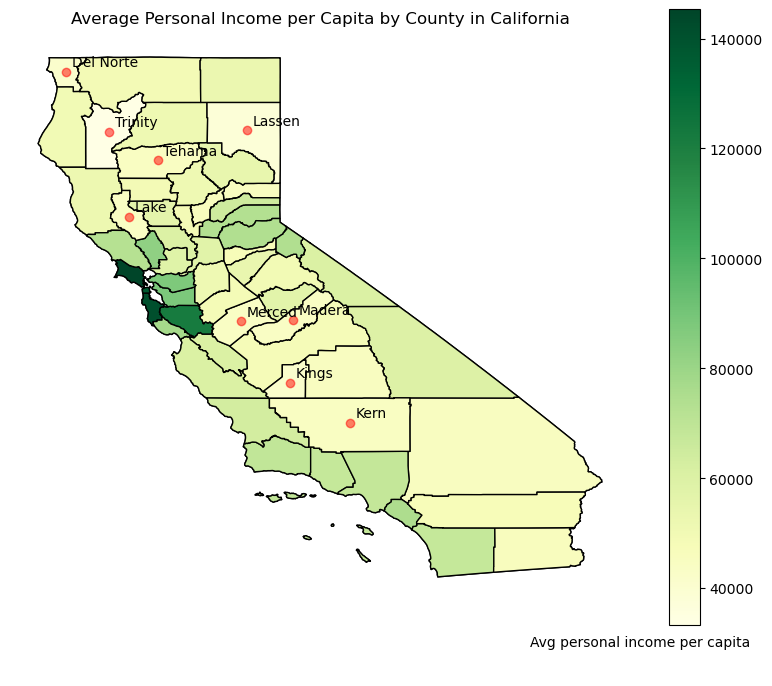

In [206]:
fig, gax = plt.subplots(figsize = (10,8))

# Plot the state level
state_df[state_df['NAME'] == 'California'].plot(ax = gax, edgecolor='black',color='white')

# Plot the counties and data
county_df_covid.plot(
    ax=gax, edgecolor='black', column='avg_personal_income_capita_2020', legend=True, cmap='YlGn' #range of your column value for the color legend
)

# Add text to let people know what we are plotting
gax.annotate('Avg personal income per capita',xy=(0.53, 0.05),  xycoords='figure fraction')
gdf.head()
# Plot county names of high personal income per capita
gdf_highquantile = gdf[gdf['avg_personal_income_capita_2020'] < gdf['avg_personal_income_capita_2020'].quantile(0.15)]
gdf_highquantile.plot(ax=gax, color='red', alpha = 0.5)
for x, y, label in zip(gdf_highquantile['Coordinates'].x, gdf_highquantile['Coordinates'].y, gdf_highquantile['county']):
    gax.annotate(label, xy=(x,y), xytext=(4,4), textcoords='offset points')


# I don't want the axis with long and lat
plt.axis('off')

# Add a title
plt.title('Average Personal Income per Capita by County in California')

plt.show()

In this map, I have highlighted the average personal income per capita in California. These locations with low average personal income per capita may respond worse to Covid-19

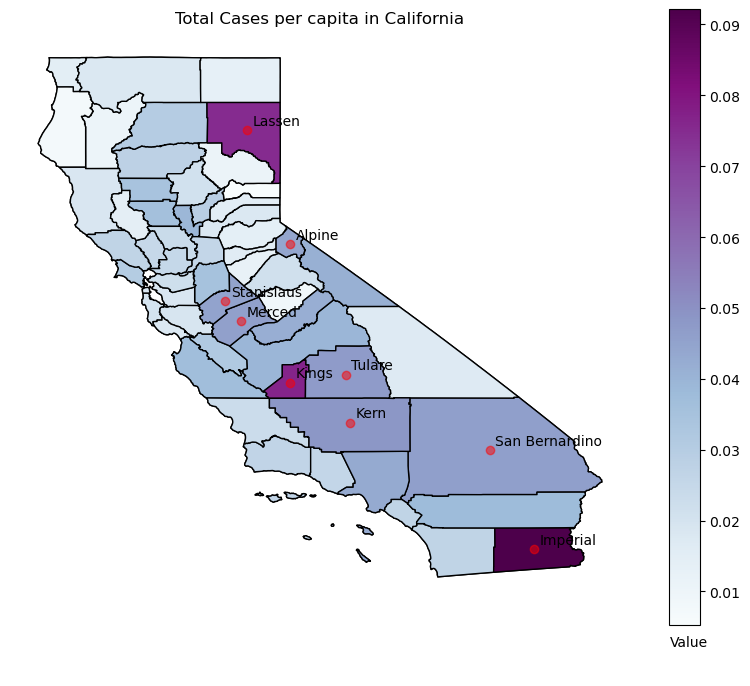

In [202]:
fig, gax = plt.subplots(figsize = (10,8))

# Plot the state level
state_df[state_df['NAME'] == 'California'].plot(ax = gax, edgecolor='black',color='white')

# Plot the counties and data
county_df_covid.plot(
    ax=gax, edgecolor='black', column='total_cases_per_capita', legend=True, cmap='BuPu' #range of your column value for the color legend
)

# Add text to let people know what we are plotting
gax.annotate('Value',xy=(0.67, 0.05),  xycoords='figure fraction')
gdf.head()
# Plot county names of high personal income per capita
gdf_highquantile = gdf[gdf['total_cases_per_capita'] > gdf['total_cases_per_capita'].quantile(0.85)]
gdf_highquantile.plot(ax=gax, color='red', alpha = 0.5)
for x, y, label in zip(gdf_highquantile['Coordinates'].x, gdf_highquantile['Coordinates'].y, gdf_highquantile['county']):
    gax.annotate(label, xy=(x,y), xytext=(4,4), textcoords='offset points')


# I don't want the axis with long and lat
plt.axis('off')

# Add a title
plt.title('Total Cases per capita in California')

plt.show()

This is a map highlighting the main response variable cases per capita. I highlight the areas with the most cases per capita. We will look for correlation between the x variables and cases.

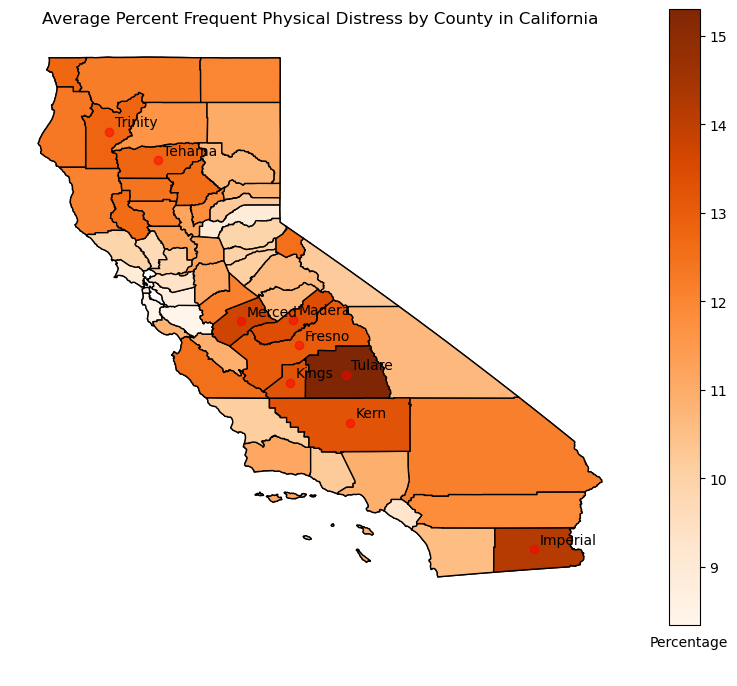

In [203]:
fig, gax = plt.subplots(figsize = (10,8))

# Plot the state level
state_df[state_df['NAME'] == 'California'].plot(ax = gax, edgecolor='black',color='white')

# Plot the counties and data
county_df_covid.plot(
    ax=gax, edgecolor='black', column='avg_percent_frequent_physical_distress', legend=True, cmap='Oranges' #range of your column value for the color legend
)

# Add text to let people know what we are plotting
gax.annotate('Percentage',xy=(0.65, 0.05),  xycoords='figure fraction')
gdf.head()
# Plot county names of high personal income per capita
gdf_highquantile = gdf[gdf['avg_percent_frequent_physical_distress'] > gdf['avg_percent_frequent_physical_distress'].quantile(0.85)]
gdf_highquantile.plot(ax=gax, color='red', alpha = 0.5)
for x, y, label in zip(gdf_highquantile['Coordinates'].x, gdf_highquantile['Coordinates'].y, gdf_highquantile['county']):
    gax.annotate(label, xy=(x,y), xytext=(4,4), textcoords='offset points')


# I don't want the axis with long and lat
plt.axis('off')

# Add a title
plt.title('Average Percent Frequent Physical Distress by County in California')


plt.show()

This is a map highlighting my main x variable considered for exploration of moderation effects, physical distress. I highlight the areas with the most physical distress. We will look for correlation between the this and cases.

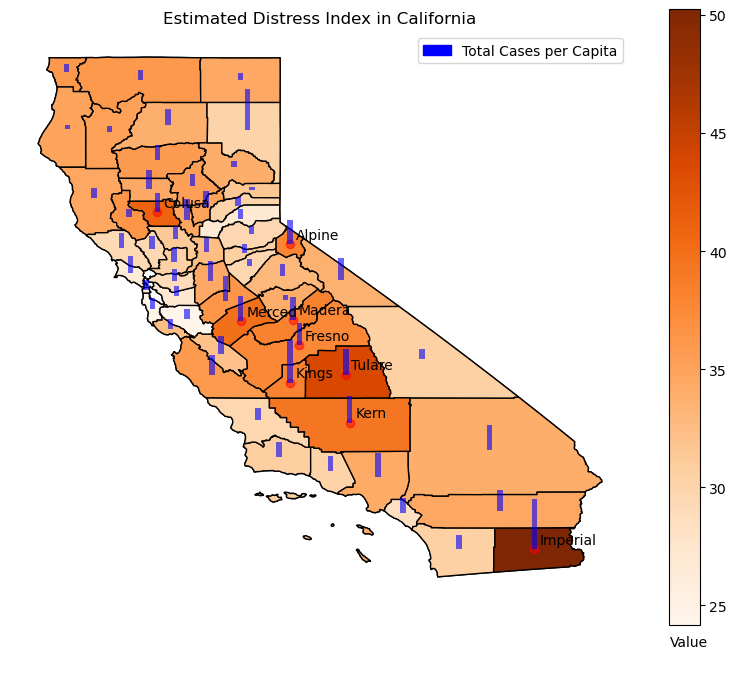

In [204]:
fig, gax = plt.subplots(figsize = (10,8))

# Plot the state level
state_df[state_df['NAME'] == 'California'].plot(ax = gax, edgecolor='black',color='white')

# Plot the counties and data
county_df_covid.plot(
    ax=gax, edgecolor='black', column='distress_index', legend=True, cmap='Oranges' #range of your column value for the color legend
)

# Add text to let people know what we are plotting
gax.annotate('Value',xy=(0.67, 0.05),  xycoords='figure fraction')
gdf.head()
# Plot county names of high personal income per capita
gdf_highquantile = gdf[gdf['distress_index'] > gdf['distress_index'].quantile(0.85)]
gdf_highquantile.plot(ax=gax, color='red', alpha = 0.5)
for x, y, label in zip(gdf_highquantile['Coordinates'].x, gdf_highquantile['Coordinates'].y, gdf_highquantile['county']):
    gax.annotate(label, xy=(x,y), xytext=(4,4), textcoords='offset points')

# Add bars representing total cases per capita
for x, y, value in zip(gdf['Coordinates'].x, gdf['Coordinates'].y, gdf['total_cases_per_capita']):
    gax.bar(x, value * 10, bottom=y, width=0.1, color='blue', alpha=0.6)

# Add a legend showing how distress_index is blue
blue_patch = mpatches.Patch(color='blue', label='Total Cases per Capita')
plt.legend(handles=[blue_patch])


# I don't want the axis with long and lat
plt.axis('off')

# Add a title
plt.title('Estimated Distress Index in California')

plt.show()

This is the ultimate map where I try to tie everything together. I combine mental, physical distress, and unemployment rate to create an index for total distress. Then plot cases as a bar on the same map so it can be easier to see the correlation between cases and distress. From this graph, I can somewhat see that areas with higher distress have higher cases on average. So, for my research question this indicates that physical distress may impact/ moderate the relationship between socioeconomic/ weather factors and cases

In [ ]:
# Word count in markdown cells 
import json

with open('Project1Code.ipynb') as json_file:
    data = json.load(json_file)


wordCount = 0
for each in data['cells']:
    cellType = each['cell_type']
    if cellType == "markdown":
        content = each['source']
        for line in content:
            temp = [word for word in line.split() if "#" not in word] # we might need to filter for more markdown keywords here
            wordCount = wordCount + len(temp)
            
print(wordCount)

867
